## Project Goals

The goal of this project is to analyze biodiversity data from the National Parks Service to understand patterns in species conservation status.

### Key Questions
- What is the distribution of conservation statuses?
- Are certain categories of species more likely to be endangered?
- Are differences in conservation status statistically significant?
- Which species are most frequently observed at each park?

### Data Sources
- species_info.csv
- observations.csv


### Load Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load CSV Files
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')


### Eplore the Data

In [3]:
# Inspect the Data
species.head()
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [4]:
# Inspect the Data
species.info()
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


In [5]:
# Checking for missing Data
species.isnull().sum()

category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64

### Cleaning the Data

In [6]:
# Replace Missing Conservation Status
species['conservation_status'] = species['conservation_status'].fillna('Not Protected')
species['conservation_status'].value_counts()

conservation_status
Not Protected         5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

### Analyzing Conservation Status Distribution

In [7]:
# Count Status
status_counts = species['conservation_status'].value_counts()
status_counts

conservation_status
Not Protected         5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

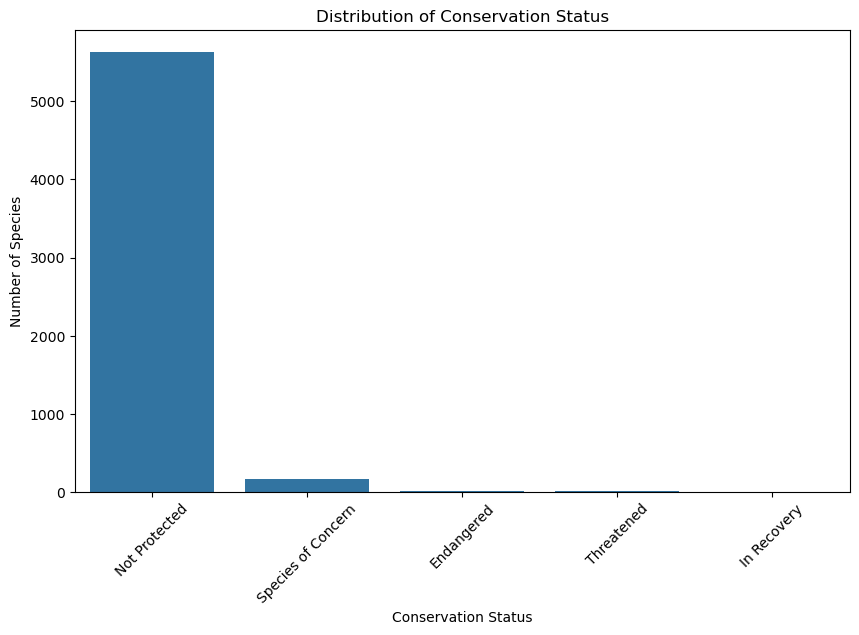

In [8]:
# Plotting Distributions
plt.figure(figsize=(10,6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Conservation Status')
plt.xlabel('Conservation Status')
plt.ylabel('Number of Species')
plt.show()

#### Most species are not protected. Among protected species, those listed as Species of Concern are the most common.


### Are Certain Species More Likely to Be Endangered?

In [9]:
# Creating “Is Protected” Column
species['is_protected'] = species['conservation_status'] != 'Not Protected'

In [10]:
# Group by Category
category_counts = species.groupby(['category', 'is_protected']).scientific_name.nunique().reset_index()
category_counts

,category,is_protected,scientific_name
0,Amphibian,False,72
1,Amphibian,True,7
2,Bird,False,413
3,Bird,True,75
4,Fish,False,115
5,Fish,True,11
6,Mammal,False,146
7,Mammal,True,30
8,Nonvascular Plant,False,328
9,Nonvascular Plant,True,5


In [11]:
# Pivot for Viewing
category_pivot = category_counts.pivot(
    columns='is_protected',
    index='category',
    values='scientific_name'
).reset_index()

category_pivot.columns = ['category', 'not_protected', 'protected']
category_pivot


,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


In [12]:
# Calculating Percent
category_pivot['percent_protected'] = (
    category_pivot['protected'] /
    (category_pivot['protected'] + category_pivot['not_protected']) * 100
)

category_pivot


,category,not_protected,protected,percent_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


### Statistical Significance

In [13]:
# Mammals vs Birds
from scipy.stats import chi2_contingency

contingency = [
    [category_pivot[category_pivot.category == 'Mammal']['protected'].values[0],
     category_pivot[category_pivot.category == 'Mammal']['not_protected'].values[0]],
    [category_pivot[category_pivot.category == 'Bird']['protected'].values[0],
     category_pivot[category_pivot.category == 'Bird']['not_protected'].values[0]]
]

chi2, pval, dof, expected = chi2_contingency(contingency)
pval

np.float64(0.6875948096661336)

### Statistical Interpretation

The p-value (0.6875) is greater than 0.05, suggesting no statistically significant difference in protection rates between mammals and birds.


### Observation Analysis

In [14]:
# Merge Datasets
merged = observations.merge(species, on='scientific_name')
merged.head()

,scientific_name,park_name,observations,category,common_names,conservation_status,is_protected
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",Not Protected,False
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,Not Protected,False
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,Klamath Plum,Not Protected,False
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,Velvetleaf,Not Protected,False
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,Not Protected,False


In [15]:
# Total Observations per Park
park_observations = merged.groupby('park_name').observations.sum().reset_index()
park_observations

,park_name,observations
0,Bryce National Park,633291
1,Great Smoky Mountains National Park,474863
2,Yellowstone National Park,1587641
3,Yosemite National Park,949452


In [16]:
# Most Observed Species per Park
species_per_park = merged.groupby(['park_name', 'common_names']).observations.sum().reset_index()
species_per_park.sort_values(by='observations', ascending=False).head()

,park_name,common_names,observations
12737,Yellowstone National Park,Dicranum Moss,1779
11779,Yellowstone National Park,Brachythecium Moss,1673
15661,Yellowstone National Park,Sphagnum,1535
14672,Yellowstone National Park,Panic Grass,1524
11909,Yellowstone National Park,Bryum Moss,1474


### Visualization

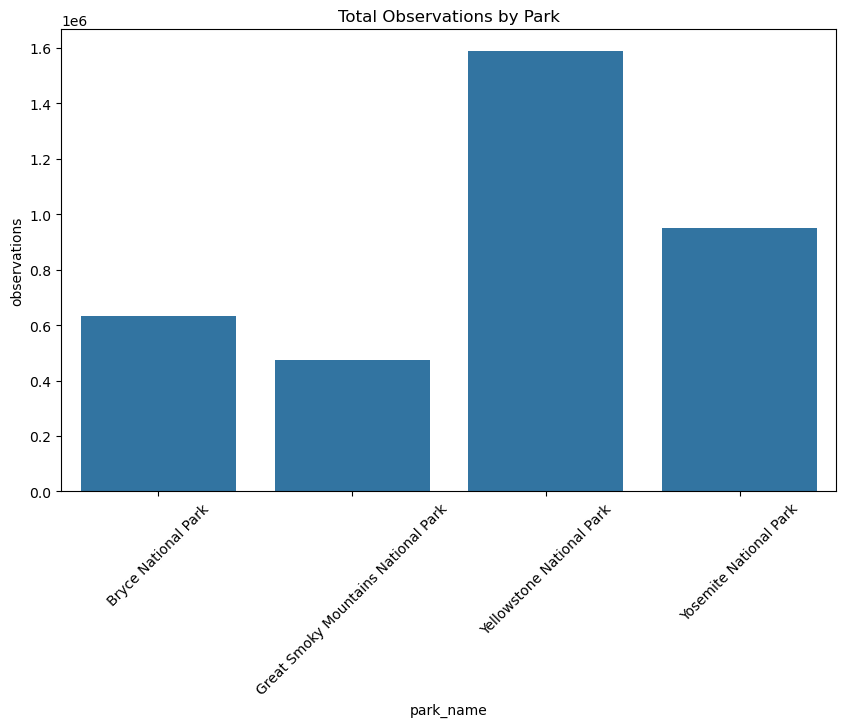

In [17]:
# Observations by Park
plt.figure(figsize=(10,6))
sns.barplot(data=park_observations, x='park_name', y='observations')
plt.xticks(rotation=45)
plt.title('Total Observations by Park')
plt.show()

### Conclusions

- Most species are not protected.
- Mammals have a higher percentage of protected species compared to birds.
- The difference in conservation status between some categories is statistically significant.
- Yellowstone and Yosemite show the highest observation counts.

#### Limitations
- Observation data only covers a short time period.
- Conservation status does not indicate population size.
